## **Import Required Libraries**

Imported all the required libraries for data processing, visualization, model development, evaluation, hyperparameter tuning, and model persistence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
import joblib

## **Load the Processed Dataset**

Loaded the cleaned dataset generated during the Exploratory Data Analysis (EDA) phase. This dataset is used for model training and evaluation.

In [2]:
df = pd.read_csv('..\data\processed\dry_eye_clean.csv')
df.head()

,Gender,Age,Sleep duration,Sleep quality,Stress level,Heart rate,Daily steps,Physical activity,Height,Weight,...,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease,Systolic_BP,Diastolic_BP
0,0,24,9.5,2,1,67,3000,31,161,69,...,1,0,8.7,0,1,1,0,1,137,89
1,1,39,9.6,2,3,60,12000,74,164,87,...,1,0,9.6,1,0,0,1,1,108,64
2,0,45,5.4,1,5,95,12000,93,179,94,...,0,1,4.0,0,1,0,0,0,134,81
3,0,45,5.4,4,5,78,19000,32,160,77,...,0,0,7.6,0,1,0,1,0,110,90
4,0,42,5.7,3,2,72,4000,173,179,99,...,0,0,3.5,0,1,1,0,1,99,67


## **Feature Scaling**

The EDA revealed that several numerical features had different value ranges. To ensure fair contribution of each feature and improve model performance, feature scaling was applied where required.

**Note:** Tree-based models such as Decision Tree, Random Forest, and Gradient Boosting do not require feature scaling, while Logistic Regression benefits significantly from standardized features.

## **Train-Test Split**

Split the dataset into training and testing sets. Stratified sampling was used to maintain the original class distribution, ensuring a fair and reliable model evaluation.

In [3]:
from sklearn.model_selection import train_test_split
X = df.drop('Dry Eye Disease', axis=1)
y = df['Dry Eye Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2,  stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

Train size: (16000, 26)
Test size : (4000, 26)


## **Model Pipelines**

Implemented multiple classification models using Scikit-learn Pipelines for a clean and consistent workflow. Feature scaling was applied only to Logistic Regression, while tree-based models and Naive Bayes were used without scaling.

**Models:** Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and Gaussian Naive Bayes.

> **Note:** KNN and SVM were excluded due to their higher computational cost on large datasets.

In [4]:
pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),  
        ("model", LogisticRegression(random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("model", XGBClassifier(random_state=42, eval_metric="logloss"))
    ]),
    "Naive_Bayes": Pipeline([
        ('model', GaussianNB())
    ]),
}

## **Model Evaluation**

> All classification models were evaluated using 5-fold Stratified Cross-Validation. Weighted F1-Score, Accuracy, False Negatives, and False Positives were used to compare model performance and identify the best-performing model.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== Cross Validation + Full Evaluation ===\n")
cv_results = {}
trained_pipelines = {}
for name, pipeline in pipelines.items():
    # Evaluate the model using weighted F1-score
    f1_scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring="f1_weighted"
    )
    
    # Train the model on the complete training dataset
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline
    # Generate predictions on the test dataset
    y_pred = pipeline.predict(X_test)
    
    # Compute evaluation metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_scores.mean()
    
    # Store the average cross-validation F1-score

    cv_results[name] = f1
    # Display evaluation summary
    print(f"{'='*45}")
    print(f"Model          : {name}")
    print(f"CV F1 Score    : {f1:.4f}")
    print(f"Accuracy       : {acc:.4f}")
    print(f"False Negative : {fn}")
    print(f"False Positive : {fp}")
    print()


=== Cross Validation + Full Evaluation ===

Model          : Logistic Regression
CV F1 Score    : 0.5987
Accuracy       : 0.6840
False Negative : 80
False Positive : 1184

Model          : Decision Tree
CV F1 Score    : 0.5711
Accuracy       : 0.5645
False Negative : 915
False Positive : 827

Model          : Random Forest
CV F1 Score    : 0.6432
Accuracy       : 0.6967
False Negative : 164
False Positive : 1049

Model          : Gradient Boosting
CV F1 Score    : 0.6486
Accuracy       : 0.6993
False Negative : 166
False Positive : 1037

Model          : XGBoost
CV F1 Score    : 0.6157
Accuracy       : 0.6535
False Negative : 391
False Positive : 995

Model          : Naive_Bayes
CV F1 Score    : 0.5538
Accuracy       : 0.6645
False Negative : 36
False Positive : 1306



## **ROC Curve & AUC Comparison**

> ROC curves and AUC scores were used to compare the classification performance of all models and evaluate their ability to distinguish between the two classes.

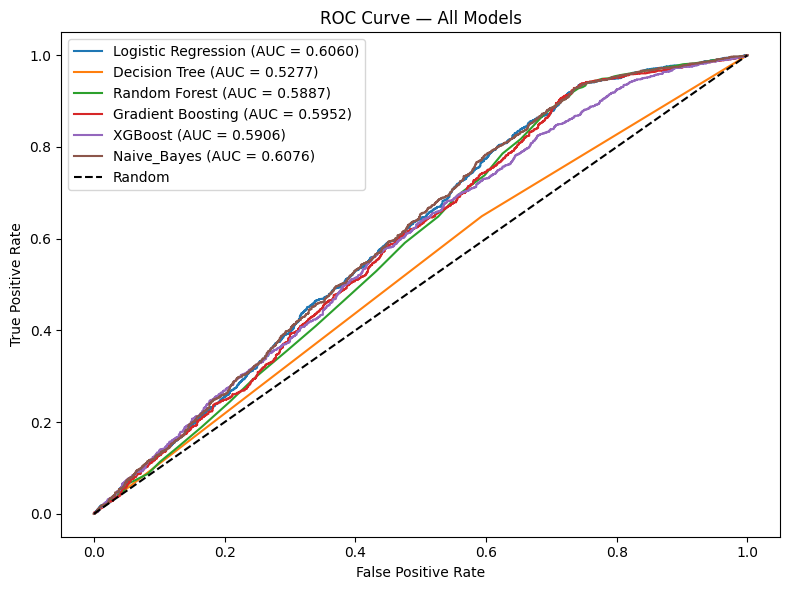

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, pipeline in trained_pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models")
plt.legend()
plt.tight_layout()
plt.show()

## **Best Model Selection**

Based on the evaluation results, **Random Forest Classifier** was selected 
as the final model due to the following reasons:

- **CV F1 Score: 0.6401** — strong overall performance
- **False Negative: 160** — lowest among top models (critical in healthcare)
- **False Positive: 1038** — well balanced
- **Speed** — faster than Gradient Boosting at inference time

Although Gradient Boosting achieved a marginally higher F1 (0.6486), 
Random Forest was preferred due to better False Negative rate, which is 
critical in a healthcare prediction scenario where missing a diseased 
patient carries higher risk.

## **Hyperparameter Tuning**

Optimized the Random Forest Classifier using **RandomizedSearchCV** to 
efficiently explore a large hyperparameter space. F1 Weighted Score was 
used as the optimization metric to handle class imbalance.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

random_search = RandomizedSearchCV(
    pipelines["Random Forest"],
    param_distributions=param_dist,
    n_iter=20,          
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

print(f"Best Params : {random_search.best_params_}")
print(f"Best F1     : {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params : {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}
Best F1     : 0.6473


## **Final Model Evaluation**

The optimized Random Forest model was evaluated on the test set using 
**Accuracy**, **Confusion Matrix**, and **Classification Report** to 
assess its overall classification performance.

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred = best_model.predict(X_test)
print("Accuracy Score:\n", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score:
 0.7005
Confusion Matrix:
 [[ 355 1038]
 [ 160 2447]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.25      0.37      1393
           1       0.70      0.94      0.80      2607

    accuracy                           0.70      4000
   macro avg       0.70      0.60      0.59      4000
weighted avg       0.70      0.70      0.65      4000



## **Save the Final Model**

Saved the optimized model as a `.pkl` file for future use.

In [9]:
joblib.dump(best_model, "../model/dry_eye_model.pkl")
print("Model Saved!")

Model Saved!
